ここでは、プログラムどうしが ネットワーク越しに通信する仕組みを、手を動かして学びましょう。

- HTTPとサーバ: HTTPの仕組み → 自分でWebサーバを立てる → クライアントで叩く → 生のTCPで通信の正体を覗く
- リアルタイム通信: HTTPの限界 → WebSocket → WebRTC

前回の「バイナリとセキュリティ」で学んだバイト列・XOR・ハッシュが、ここで実際の通信の中に現れます。最後の総仕上げでは、サーバと対戦する数当てbot を作ります。

# HTTP とサーバ

## HTTP とは

Webの通信の大部分は HTTP というプロトコルで行われます。基本は、リクエストを送るとレスポンスが返る、の一往復です。

- メソッド: 何をしたいか。`GET` や `POST` など
- URL / パス: どこに対して。`/hello` など
- ステータスコード: 送った結果どうなったか。`200` は成功、`404` は見つからない、`500` はサーバ側エラー
- ヘッダ: `Content-Type` などの付随情報
- ボディ: 本文データ

まずは自分でサーバを立てて、この往復を体験します。

## 自分の Web サーバを立てる

Pythonの標準ライブラリ `http.server` で、小さなWebサーバを作れます。`do_GET` / `do_POST` に「リクエストが来たら何を返すか」を書きます。

サーバは待ち受けて動き続けるので、ノートブックが固まらないよう 別スレッド で起動します。下のセルを実行すると、`localhost` の空きポートでサーバが立ち上がります。

> `__init__` が無いのはなぜ？ `class MyHandler(BaseHTTPRequestHandler)` の括弧の中が 親クラスで、`MyHandler` はそれを 継承 しています。`__init__` は親クラスがやってくれるので自分では書かず、`do_GET` / `do_POST` などの メソッドを足すだけ でよいのです。

In [ ]:
import json, threading, time
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

class MyHandler(BaseHTTPRequestHandler):
    def _send_json(self, code, obj):
        body = json.dumps(obj, ensure_ascii=False).encode()
        self.send_response(code)                       # ステータスコード
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)                         # ボディを書き込む

    def do_GET(self):
        if self.path == "/hello":
            self._send_json(200, {"message": "こんにちは"})
        else:
            self._send_json(404, {"error": "not found"})

    def do_POST(self):
        if self.path == "/":
            length = int(self.headers.get("Content-Length", 0))
            raw = self.rfile.read(length)
            data = json.loads(raw or b"{}")   # 送られてきたJSON
            self._send_json(200, {"あなたが送ったデータ": data})
        else:
            self._send_json(404, {"error": "not found"})

    def log_message(self, *args):
        pass   # アクセスログは出さない

server = ThreadingHTTPServer(("127.0.0.1", 0), MyHandler)  # 0 = 空きポートを自動選択
PORT = server.server_address[1]
BASE = "http://127.0.0.1:{}".format(PORT)
threading.Thread(target=server.serve_forever, daemon=True).start()
time.sleep(0.3)
print("サーバ起動:", BASE)

## 練習問題1: スコアをサーバにためてランキングを返す

`POST /score` に `{"name": ..., "score": ...}` を送るとサーバが `scores` リストにためて、`GET /ranking` で一覧を返す——というサーバです。

やること
1. サーバの `do_POST` の中に、受け取った `data` を `scores` に追加する処理を書く
2. 次の空のセルに、`requests` でスコアを2つ送ってから `/ranking` を表示するコードを書く

期待される動作: 送った2件が `/ranking` に一覧で並ぶ。

In [ ]:
import json, threading, time, requests
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

scores = []   # サーバがためていくスコアのリスト

class RankingHandler(BaseHTTPRequestHandler):
    def _send_json(self, code, obj):
        body = json.dumps(obj, ensure_ascii=False).encode()
        self.send_response(code)
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.end_headers()
        self.wfile.write(body)

    def do_POST(self):
        if self.path == "/score":
            length = int(self.headers.get("Content-Length", 0))
            raw = self.rfile.read(length)
            data = json.loads(raw)   # 例: {"name": ..., "score": ...}

            # ここに、受け取った data を scores に追加する処理を書く


            self._send_json(200, {"ok": True, "count": len(scores)})
        else:
            self._send_json(404, {"error": "not found"})

    def do_GET(self):
        if self.path == "/ranking":
            self._send_json(200, scores)
        else:
            self._send_json(404, {"error": "not found"})

    def log_message(self, *a):
        pass

srv2 = ThreadingHTTPServer(("127.0.0.1", 0), RankingHandler)
p2 = srv2.server_address[1]
threading.Thread(target=srv2.serve_forever, daemon=True).start()
time.sleep(0.3)
URL = "http://127.0.0.1:{}".format(p2)
print("ランキングサーバ起動:", URL)

In [ ]:
# ここに自分でコードを書く：
#   1) スコアの辞書を2つ、URL + "/score" に requests.post で送る
#   2) URL + "/ranking" を取得して表示する




## クライアントでサーバにリクエストを送る

サーバに リクエストを送る側 がクライアントです。ここでは `requests`を使い、辞書をそのまま送って、返事も辞書で受け取れます。

- `requests.get(URL)` … GETで取得
- `requests.post(URL, json=辞書)` … 辞書をJSONとして送る
- 返事の `.json()` で 辞書 に、`.status_code` でステータスコードが分かる

In [ ]:
import requests

# --- GET ---
res = requests.get(BASE + "/hello")
print("ステータス:", res.status_code)          # 200
print("Content-Type:", res.headers["Content-Type"])
print("ボディ:", res.json())              # {'message': 'こんにちは'}

# --- POST: 辞書をそのまま送る ---
res = requests.post(BASE + "/", json={"name": "太郎", "score": 90})
print("POSTの返事:", res.json())

## 練習問題2: クライアントで送って、返事を読む

さっき立てたサーバ `BASE` に、`POST` で `{"name": "花子"}` を送り、返ってきた返事を 辞書として 受け取って表示するコードを、下のセルに 自分で 書いてください。

ヒント: 「クライアントでサーバにリクエストを送る」のセルと同じやり方です。

In [ ]:
import requests

# BASE + "/" に {"name": "花子"} を送り、返事を辞書で受け取って表示する




## HTTP の正体は「ただのテキスト」

HTTPは、実は TCP という土管の上を流れる、決まった書式のテキスト にすぎません。`socket` で生のTCP接続を開き、HTTPリクエストを 手で組み立てて 送ってみると、それがよく分かります。

リクエストの1行目は `メソッド パス プロトコル`、続いてヘッダ、空行、ボディ、という構造です。

In [ ]:
import socket

sock = socket.create_connection(("127.0.0.1", PORT))
# HTTPリクエストを自分で文字列として組み立てて送る
request_text = "GET /hello HTTP/1.1\r\nHost: localhost\r\nConnection: close\r\n\r\n"
sock.sendall(request_text.encode())

# 生のレスポンスを受け取る
raw = b""
while True:
    chunk = sock.recv(4096)
    if not chunk:
        break
    raw += chunk
sock.close()

print(raw.decode())   # ステータス行・ヘッダ・空行・ボディ が全部テキストで見える

## 練習問題3: 生socketでステータス行を読む

`socket` でさっきのサーバに生のHTTP `GET /hello` を送り、レスポンスの1行目、ステータス行だけを表示してください。接続と受信のループは用意してあります。

やること
- `GET /hello` の生リクエスト文字列を作って送る。上の『HTTPの正体』のセルと同じ形です
- 受け取った `raw` を `.decode()` して、`.split()` で行に分け、先頭のステータス行を表示する

In [ ]:
import socket

sock = socket.create_connection(("127.0.0.1", PORT))

# ここに、GET /hello の生HTTPリクエスト文字列を作って送る


raw = b""
while True:
    chunk = sock.recv(4096)
    if not chunk:
        break
    raw += chunk
sock.close()

# raw を文字列にして、最初の行を取り出して表示する



## HTML や JavaScript を配信する

これまでサーバはプログラムが読むためのJSONを返していました。でも ブラウザ向けには HTML を返します。返すときに `Content-Type: text/html` と伝えると、ブラウザはそれを Webページ として表示します。

さらに、HTMLの中に `<script> ... </script>` を書くと、ブラウザ側で JavaScript が動きます。ボタンを押す、`fetch` でサーバへデータを取りに行く——普通のWebサイトはこうやって動いています。対戦ゲームの盤面 も、サーバがHTMLを配信し、その中のJSが `/state` を取りに来る、という同じ仕組みです。

まず下のセルで、配信するWebページを `page.html` というファイルに書き出します。1行目の `%%writefile` は、セルの中身をそのままファイルに保存する命令です。次のサーバがそれを `GET /` で配信し、ページ内のJSが1秒ごとに `GET /time` を呼んで時刻を更新します。

やってみよう: `page.html` の中の `<h1>` の文字や、ボタンを押したときの `alert(...)` の文字を変えて、2つのセルを実行し直すと表示が変わります。

In [ ]:
%%writefile page.html
<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>配信デモ</title>
</head>
<body style="font-family: sans-serif; text-align: center; margin-top: 30px">
  <h1>サーバが配信するページ</h1>
  <p>サーバの時刻: <span id="t">-</span></p>
  <button onclick="alert('ボタンが押されました！')">押してみて</button>
  <script>
    // ここはブラウザ側で動くJavaScript。1秒ごとにサーバの /time を取りに行く
    async function update() {
      const res = await fetch('/time');
      const data = await res.json();
      document.getElementById('t').textContent = data.time;
    }
    setInterval(update, 1000);
    update();
  </script>
</body>
</html>


In [ ]:
import json, threading, time
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from datetime import datetime

class WebHandler(BaseHTTPRequestHandler):
    def do_GET(self):
        if self.path == "/time":                      # JSの fetch に JSON を返す
            now = datetime.now().strftime("%H:%M:%S")
            body = json.dumps({"time": now}).encode()
            self.send_response(200)
            self.send_header("Content-Type", "application/json")
            self.end_headers()
            self.wfile.write(body)
        elif self.path == "/":                         # トップページは page.html を返す
            with open("page.html", encoding="utf-8") as f:
                body = f.read().encode()
            self.send_response(200)
            self.send_header("Content-Type", "text/html; charset=utf-8")   # ← HTMLだと伝える
            self.end_headers()
            self.wfile.write(body)
        else:
            self.send_response(404)
            self.end_headers()
    def log_message(self, *a):
        pass

web = ThreadingHTTPServer(("127.0.0.1", 0), WebHandler)
WPORT = web.server_address[1]
threading.Thread(target=web.serve_forever, daemon=True).start()
time.sleep(0.3)
print("Webサーバ起動: http://127.0.0.1:%d/" % WPORT)

# Colabなら、このページをノート内に表示できる
try:
    from google.colab.output import serve_kernel_port_as_iframe
    serve_kernel_port_as_iframe(WPORT, path="/")
except Exception:
    print("ブラウザで http://127.0.0.1:%d/ を開いてください" % WPORT)

# リアルタイム通信

## HTTP の限界

HTTPは 「クライアントが聞いて、サーバが答える」一問一答 です。サーバ側から自発的に「今こうなったよ」と送りつけることはできません。

チャットや対戦ゲームのように サーバの状態が刻々と変わる 場合、HTTPだと「変化ありましたか？」を何度も聞き続けるポーリングしかなく、無駄が多く遅れます。

そこで登場するのが WebSocket です。

## WebSocket — 双方向・つなぎっぱなし

WebSocket は、一度つなぐと 接続を保ったまま、両方向にいつでもデータを送り合える 通信です。

面白いのは 始まり方 です。WebSocketは最初、ふつうの HTTPで「これからWebSocketに切り替えたい」と `Upgrade` をお願いします。このとき、クライアントが送った `Sec-WebSocket-Key` から、サーバは決まった計算で `Sec-WebSocket-Accept` を作って返します。これが一致して初めて接続が成立します。

計算は、鍵と決まった呪文 GUID をつないで SHA-1 して base64 するだけ。前回のハッシュ・base64がそのまま出てきます。

前回の復習: 使う道具
- 文字列をバイト列にする: `文字列.encode()`
- SHA-1のハッシュを バイト列 で得る: `hashlib.sha1(バイト列).digest()`。`.hexdigest()` だと16進の文字列になるので、ここでは `digest()` を使います
- バイト列を base64 の 文字列 にする: `base64.b64encode(バイト列).decode()`

In [ ]:
import hashlib, base64

GUID = "258EAFA5-E914-47DA-95CA-C5AB0DC85B11"   # WebSocketの決まった呪文

def websocket_accept(client_key):
    return base64.b64encode(hashlib.sha1((client_key + GUID).encode()).digest()).decode()

# 仕様書の例で確かめる
print(websocket_accept("dGhlIHNhbXBsZSBub25jZQ=="))   # s3pPLMBiTxaQ9kYGzzhZRbK+xOo=

## 練習問題4: WebSocketの `Sec-WebSocket-Accept` を計算する

クライアントから届いた `client_key` に対して、サーバが返すべき `Sec-WebSocket-Accept` を計算する関数を完成させてください。

ヒント: 上のWebSocket解説の計算を思い出しましょう。`client_key` と `GUID` をつないで、前回学んだ SHA-1 と base64 で作ります。`hashlib` と `base64` ライブラリが使えます。

期待される出力: `s3pPLMBiTxaQ9kYGzzhZRbK+xOo=`

In [ ]:
import hashlib, base64
GUID = "258EAFA5-E914-47DA-95CA-C5AB0DC85B11"

def websocket_accept(client_key):
    # client_key と GUID をつないで SHA-1 → digest → base64 → .decode() で文字列
    pass

print(websocket_accept("dGhlIHNhbXBsZSBub25jZQ=="))   # s3pPLMBiTxaQ9kYGzzhZRbK+xOo=

## WebSocketのフレームと「マスク」＝ XOR

WebSocketでは、データを フレーム という単位で送ります。そして クライアント→サーバのデータは必ず XOR でマスクされる決まりです。

ここで前回の XOR が本当に出てきます。4バイトのマスク鍵で各バイトをXORしてあるので、同じ鍵でもう一度XORすれば元に戻ります。`a ^ b ^ b == a` だからです。

下は、マスクされたペイロードを解除する例です。

In [ ]:
def unmask(payload, mask):
    # payload の各バイトを、4バイトの mask で順番にXORする
    return bytes(payload[i] ^ mask[i % 4] for i in range(len(payload)))

mask = bytes([0x37, 0xfa, 0x21, 0x3d])
masked = bytes.fromhex("7f93")      # マスク済みの2バイト
plain = unmask(masked, mask)
print("解除結果:", plain.decode())   # Hi

## 練習問題5: WebSocketフレームのマスクを解く

サーバが受け取った、マスク済みのペイロード `masked` と 4バイトの `mask` があります。元のテキストに戻してください。

ヒント: 前回学んだ XOR `^` を使います。4バイトの `mask` を繰り返し当てる——上のマスク解除と同じ考え方です。

期待される出力: `HELLO`

In [ ]:
masked = bytes.fromhex("cab68f76cd")
mask = bytes([0x82, 0xf3, 0xc3, 0x3a])

def unmask(payload, mask):
    # payload の各バイトを mask とXORして bytes にまとめる
    pass

plain = unmask(masked, mask)
print(plain.decode())   # HELLO

## WebRTC — ブラウザ同士の直接通信

HTTPやWebSocketは、必ず サーバを経由 します。これに対し WebRTC は、ブラウザ同士が直接、つまり P2P でデータや音声・映像をやり取りする技術です。ビデオ通話などで使われています。

ただし、いきなり相手に直接つなぐことはできません。次の段取りが必要です。

1. シグナリング: 「私はここにいます」という接続情報を、最初だけ何らかの方法で相手に渡す。この受け渡し役はサーバが担います
2. ICE / STUN / TURN: おたがいの住所の候補、ICE候補を集めて、つながる経路を探す。家庭やオフィスは NAT の内側にいて直接見えないことが多く、STUN サーバに「私の外から見た住所は？」と聞いたり、どうしてもダメなら TURN サーバに中継してもらったりします
3. つながったら、あとは 直接 データが流れます

> P2Pは ICE候補の交換で自分のIPアドレスが相手に見えます。また学校や社内のネットワークは、端末どうしの直接通信を 遮断していることが多く、WebRTCが繋がらないことがあります。

まずは、実際に動いているビデオ会議の通信を覗いて、この段取りが本当に行われていることを自分の目で確かめます。

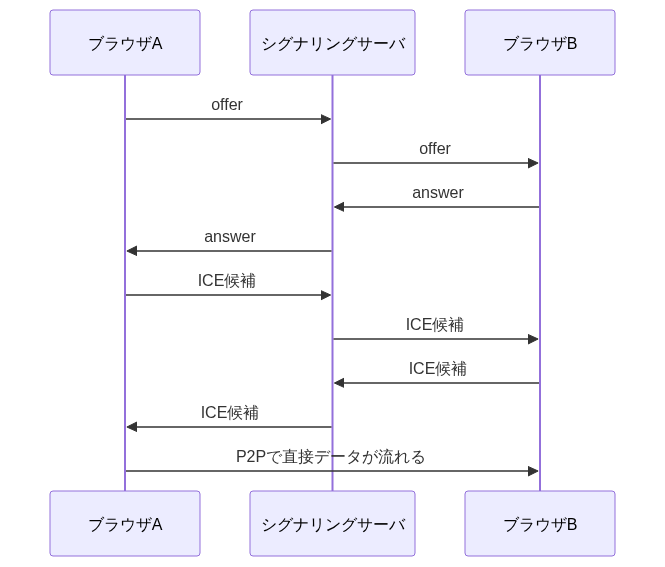


## まず実物を見る: ビデオ会議の通信を覗く

教材は Google Meet と、Chromeに標準で入っている観察ツール `chrome://webrtc-internals` です。

`chrome://webrtc-internals` は、いまブラウザの中で動いているWebRTC接続をすべて一覧できるページです。offer の中身、集まったICE候補、実際に選ばれた通信経路、流れたバイト数がリアルタイムで見えます。開いた後に作られた接続だけが記録されるので、先に開いておくのがコツです。

手順は次の3つです。順番が大事です。

1. 新しいタブで `chrome://webrtc-internals` を開いておく
2. 先生が板書したMeetのURLに参加する。カメラとマイクは無くて大丈夫です。「カメラとマイクが見つかりません」と出ても、そのまま参加すれば 受信専用 の参加者になります
3. 先生の映像が映ったら、webrtc-internals のタブに戻って観察する

## 観察してみよう

1. イベントの一覧から `createOffer` や `setLocalDescription` を探してクリックしてください。`v=0` で始まる長いテキストが出てきます。これが offer の実物です。SDP という書式で書かれています。「自分はどんな通信ができるか」を相手に伝える設定書で、読み方はこの後学びます
2. `icecandidate` や `addIceCandidate` のイベントに、`candidate:` で始まる行が次々に記録されていきます。これが ICE候補、つまり住所の候補の実物です。1回の接続でこんなに集めていることが分かります
3. 接続先のIPアドレスを見てください。つながっている相手は先生のPCではなく、Googleのサーバです。ビデオ会議のような多人数の通信は、P2PではなくSFUと呼ばれる中継サーバに全員がつなぐ形をとります。全員とP2Pを張ると接続数が人数の2乗で増えてしまうからです
4. 受信側の `inbound-rtp` にある `bytesReceived` や `framesReceived` が増え続けるのを確かめてください。逆に送信側の統計はほぼ動きません。カメラもマイクも無いあなたは受信するだけの参加者だからです。SDPでいう `recvonly` の状態です
5. 先生がカメラをOFFにしたり、レンズを手で覆ったりします。そのとき `framesReceived` やビットレートのグラフがどう反応するか、見ていてください。動きが少ない映像は圧縮が効いてビットレートが下がる、という圧縮の性質が数字で見えます

## プログラムで再現する

いまMeetで見た offer・ICE候補・P2P接続を、今度はノートの中で小さく再現します。

次の2つのセルは、`webrtc.html` を書き出して表示します。1つのページの中で2つのピアを用意して互いに接続するデモで、集まった ICE候補 と、DataChannel で送り合う ping / pong が表示されます。

In [ ]:
%%writefile webrtc.html
<div id="log" style="font-family: monospace; white-space: pre-wrap; font-size: 13px;
     background: #111; color: #0f0; padding: 10px; border-radius: 6px;"></div>
<script>
  const log = (m) => { document.getElementById('log').textContent += m + "\n"; };

  async function run() {
    const pc1 = new RTCPeerConnection();   // プレイヤーA
    const pc2 = new RTCPeerConnection();   // プレイヤーB

    // ICE候補をお互いに渡す。ここでは同じページ内なので直接渡せる
    pc1.onicecandidate = e => {
      if (e.candidate) {
        log("A の ICE候補: " + e.candidate.candidate);
        pc2.addIceCandidate(e.candidate);
      }
    };
    pc2.onicecandidate = e => {
      if (e.candidate) {
        pc1.addIceCandidate(e.candidate);
      }
    };

    // A が DataChannel を作る
    const dc = pc1.createDataChannel("chat");
    dc.onopen = () => {
      log("P2P接続 成立 → A が送信: ping");
      dc.send("ping");
    };
    dc.onmessage = e => log("A が受信: " + e.data);
    pc2.ondatachannel = e => {
      const ch = e.channel;
      ch.onmessage = m => {
        log("B が受信: " + m.data + " → B が pong を返信");
        ch.send("pong");
      };
    };

    // シグナリング: offer / answer の交換
    const offer = await pc1.createOffer();
    await pc1.setLocalDescription(offer);
    await pc2.setRemoteDescription(offer);
    const answer = await pc2.createAnswer();
    await pc2.setLocalDescription(answer);
    await pc1.setRemoteDescription(answer);
    log("offer/answer を交換しました。次に ICE候補を集めて交換します...");
  }

  run().catch(e => log("エラー: " + e));
</script>


In [ ]:
from IPython.display import HTML, display

# 上のセルで書き出した webrtc.html を読み込んで、このノート内に表示する
with open("webrtc.html", encoding="utf-8") as f:
    html = f.read()
display(HTML(html))

実行すると、`ICE候補: candidate:... typ host ...` のような行が並び、最後に `ping` → `pong` が流れるはずです。

- `typ host` … 自分のLAN内の住所。同じ機械・同じLANならこれで繋がります
- `typ srflx` … STUN経由で分かった、NATの外から見た住所

## offer / answer / ICE候補 の中身を読む

シグナリングでやり取りする中身は、実は ただのテキスト です。

offer / answer は SDP という書式で、「自分はどんな通信ができるか」を書いた設定書です。例:
```
v=0
o=- 4611731400430051336 2 IN IP4 127.0.0.1
s=-
t=0 0
m=application 9 UDP/DTLS/SCTP webrtc-datachannel   ← DataChannel を使う宣言
a=ice-ufrag:F7gI
a=fingerprint:sha-256 12:AB:...                     ← 暗号化のための指紋
```

ICE候補 … 「自分の住所の候補」。例:
```
candidate:1 1 UDP 2122260223 192.168.1.5 54321 typ host
candidate:2 1 UDP 1686052607 203.0.113.7 51000 typ srflx raddr 192.168.1.5 rport 54321
```
`typ` の後が種類です。`host` はLAN内、`srflx` はNATの外側、`relay` はTURN中継。

次のセルで、あなたのブラウザが作った本物の offer と ICE候補 を表示します。

In [ ]:
%%html
<div id="log" style="font-family: monospace; white-space: pre-wrap; font-size: 12px;
     background: #111; color: #0f0; padding: 10px; border-radius: 6px; max-height: 320px; overflow: auto;"></div>
<script>
  const log = (m) => { document.getElementById('log').textContent += m + "\n"; };

  async function run() {
    const pc = new RTCPeerConnection({ iceServers: [{ urls: "stun:stun.l.google.com:19302" }] });
    pc.createDataChannel("chat");            // これが無いと offer が空になる
    pc.onicecandidate = e => {
      if (e.candidate) log("ICE候補: " + e.candidate.candidate);
      else log("（ICE候補の収集おわり）");
    };
    const offer = await pc.createOffer();
    await pc.setLocalDescription(offer);     // ここで ICE候補の収集が始まる
    log("===== あなたの offer (SDP) =====");
    log(offer.sdp);
    log("===== あなたの ICE候補 =====");
  }

  run().catch(e => log("エラー: " + e));
</script>


## 練習問題6: 自分の offer / ICE候補を読み解く

上のセルを実行すると、あなたのブラウザが作った offer(SDP) と ICE候補が表示されます。実物を見て、次を読み解いてください。答えは環境によって違うので、自分の画面に出た値で考えます。

1. offer(SDP) の中に `m=application ... webrtc-datachannel` の行はありますか？ DataChannel を使う宣言です
2. `typ host` の候補に出ている IPアドレス は何ですか？ 自分のLAN内のIPです。`.local` なら mDNS で隠されています
3. `typ srflx` の候補は出ましたか？ 出たなら、その IP は STUN経由で分かった、外から見た自分の住所です。出なければ、STUN に到達できない環境かもしれません。
4. `typ relay` は出ましたか？ TURN を設定していないので、通常は出ません

上で学んだ host / srflx / relay と、自分の画面の実物を対応づけてみましょう。

🌶️ ノートのデモを本当に2台のPCでやるには、offer と answer の文字列を何らかの方法で相手に渡す、つまりシグナリングをするだけでよく、チャットや紙に書いて渡しても成立します。そういう「コピペでつなぐP2Pチャット」を作るのは、バイブコーディング制作回のテーマにも向いています。

## 練習問題7: サーバと対戦する数当てbot

サーバは `1`〜`100` の秘密の数を持っています。`POST /guess` に `{"number": 50}` を送ると `{"result": "correct" / "low" / "high"}` が返ります。`low` は秘密の数がもっと大きいという意味です。

サーバは用意してあります。次の2つを書いてください。
1. `ask(number)`：`URL` に数を送って `"correct"/"low"/"high"` を受け取る関数
2. その `ask` を使って、二分探索で当てる bot。当たるまで繰り返し、`N回で当たりました！ 答えは XX` と表示する

期待される動作: 7回以内で当たる。当たると、サーバは秘密の数を新しい乱数にリセットします。

In [ ]:
import json, threading, time, random, requests
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

# --- 数を当てる相手のサーバ ---
class GuessServer(BaseHTTPRequestHandler):
    secret = random.randint(1, 100)
    def do_POST(self):
        if self.path != "/guess":
            self.send_response(404)
            self.end_headers()
            return
        length = int(self.headers.get("Content-Length", 0))
        raw = self.rfile.read(length)
        data = json.loads(raw)
        guess = data["number"]
        result = "correct" if guess == GuessServer.secret else ("low" if guess < GuessServer.secret else "high")
        if result == "correct":
            GuessServer.secret = random.randint(1, 100)   # 当たったら次の数にリセット
        body = json.dumps({"result": result}).encode()
        self.send_response(200)
        self.send_header("Content-Type","application/json")
        self.end_headers()
        self.wfile.write(body)
    def log_message(self, *args):
        pass

gs = ThreadingHTTPServer(("127.0.0.1", 0), GuessServer)
gport = gs.server_address[1]
threading.Thread(target=gs.serve_forever, daemon=True).start()
time.sleep(0.3)
URL = "http://127.0.0.1:{}/guess".format(gport)


In [ ]:
# 1) ask(number): URL に {"number": number} を送って "correct"/"low"/"high" を返す
def ask(number):
    pass

# 2) ask を使って、二分探索で数を当てる bot を書く


## 🌶️ Gradio で数当てゲームに画面をつける

練習問題7で対戦したサーバを、今度は人間が遊べるようにします。サーバはそのまま使い、Gradioの画面の骨組みも用意してあります。サーバを止めてしまった場合は、練習問題7のサーバのセルを実行し直してください。

やること: `guess_ui(n)` の中身を書く。予想 `n` をサーバ `URL` に送り、返事の `result` に応じて「正解！」「もっと大きい」「もっと小さい」のメッセージを返します。送り方は練習問題2と同じ形です。

ブラウザ → Gradio → `requests` → サーバ と流れます。できた人は、`tries` に数えてある予想回数もメッセージに足してみましょう。正解したら `0` に戻すのを忘れずに。


In [ ]:
!pip install --quiet gradio

In [ ]:
import requests
import gradio as gr

tries = 0   # いま何回目の予想か

# 予想 n をサーバ URL に送り、返ってきた result に応じて
# 「正解！」「もっと大きい」「もっと小さい」のメッセージを返す
def guess_ui(n):
    global tries    # 関数の中から、外の変数 tries を書き換えるための宣言
    tries += 1
    number = int(n)
    pass

demo = gr.Interface(
    fn=guess_ui,
    inputs=gr.Number(label="予想する数（1〜100）"),
    outputs=gr.Textbox(label="ヒント"),
    title="数当てゲーム",
    description="ブラウザ → Gradio → requests → 判定サーバ、と流れます。",
)
demo.launch(share=True)   # share=True で公開URLが出る
